# Clustering Algorithms: Visual Experiments

This notebook provides a compact practical comparison of four clustering algorithms:

- K-Means
- Agglomerative Clustering
- DBSCAN
- Gaussian Mixture Models

The objective is not to build a predictive model, but to observe how different clustering approaches interpret the same unlabeled dataset.

## Experimental Questions

1. How can an appropriate number of clusters be estimated?
2. How does each algorithm partition the same dataset?
3. Which algorithms handle non-spherical shapes more effectively?
4. How should clustering results be interpreted without labels?

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.datasets import make_moons
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

IMAGES_DIR = Path("../images")
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Synthetic Dataset

A two-dimensional moon-shaped dataset is used because its geometry makes the differences between clustering approaches easier to observe.

The true labels generated by `make_moons` are not used to train the algorithms. They are kept only as a reference for understanding the dataset structure.

In [12]:
X, reference_labels = make_moons(
    n_samples=500,
    noise=0.08,
    random_state=RANDOM_STATE,
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dataset = pd.DataFrame(
    X_scaled,
    columns=["feature_1", "feature_2"],
)

dataset.head()

,feature_1,feature_2
0,0.370873,-1.345210
1,0.289497,1.146542
2,0.609962,-1.470496
3,-0.904697,1.424732
4,-0.219690,1.706951


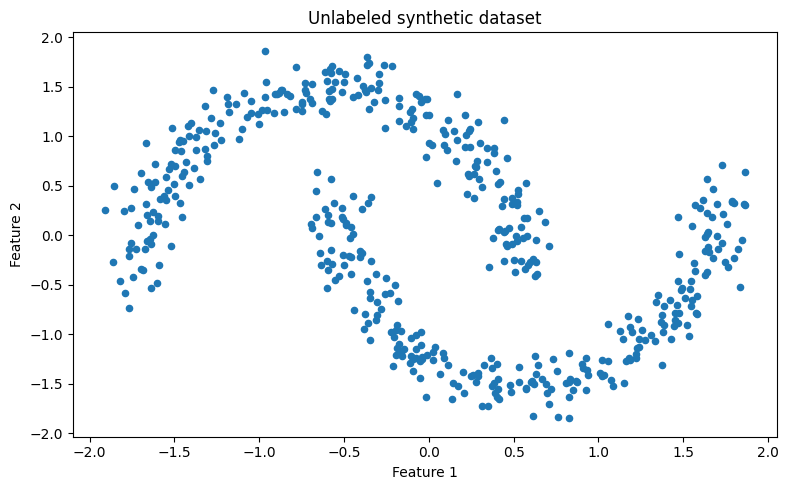

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=20)
plt.title("Unlabeled synthetic dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "unlabeled_dataset.png", dpi=200)
plt.show()

## 2. Selecting K with the Elbow Method

K-Means requires the number of clusters to be defined before training.

The Elbow Method compares the model inertia for several values of `k`. A useful value is often located where additional clusters stop producing substantial reductions in inertia.

In [14]:
k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=10,
    )
    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

evaluation_results = pd.DataFrame(
    {
        "k": list(k_values),
        "inertia": inertias,
        "silhouette_score": silhouette_scores,
    }
)

evaluation_results

,k,inertia,silhouette_score
0,2,419.118569,0.493200
1,3,306.854859,0.447876
2,4,203.487509,0.439945
3,5,146.919243,0.473072
4,6,115.803581,0.487265
5,7,92.541279,0.492196
6,8,74.195592,0.495105


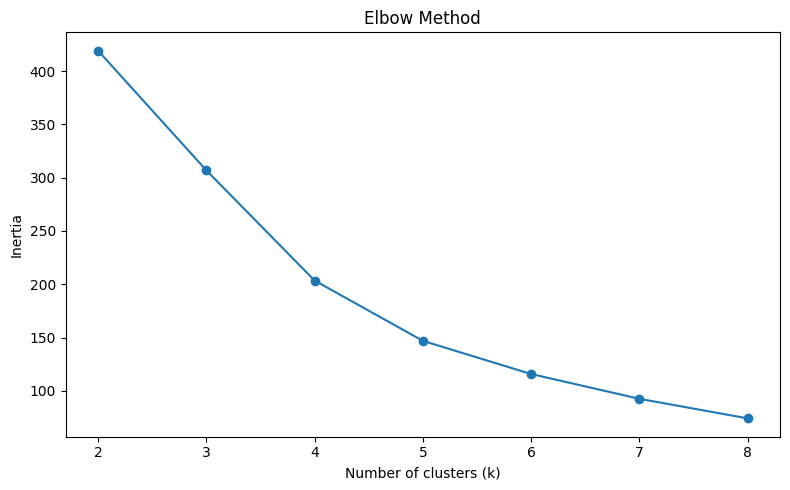

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(evaluation_results["k"], evaluation_results["inertia"], marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.tight_layout()
plt.savefig(IMAGES_DIR / "elbow_method.png", dpi=200)
plt.show()

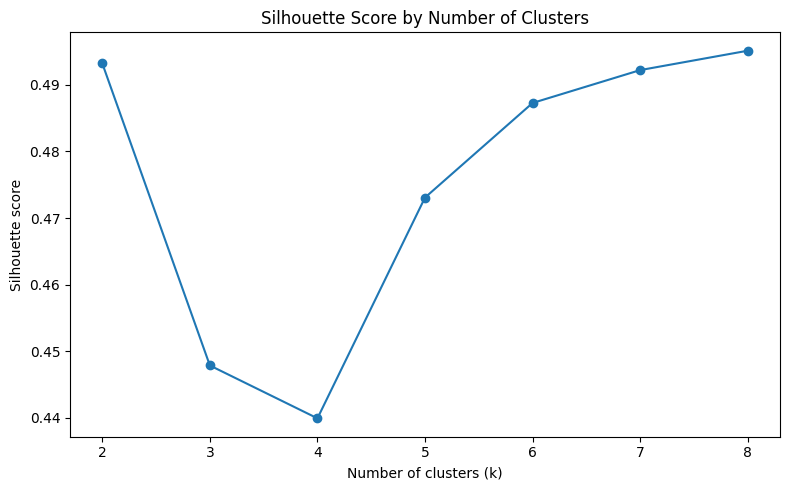

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(
    evaluation_results["k"],
    evaluation_results["silhouette_score"],
    marker="o",
)
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.xticks(list(k_values))
plt.tight_layout()
plt.savefig(IMAGES_DIR / "silhouette_scores.png", dpi=200)
plt.show()

In [17]:
models = {
    "K-Means": KMeans(
        n_clusters=2,
        random_state=RANDOM_STATE,
        n_init=10,
    ),
    "Agglomerative": AgglomerativeClustering(
        n_clusters=2,
        linkage="ward",
    ),
    "DBSCAN": DBSCAN(
        eps=0.25,
        min_samples=5,
    ),
    "GMM": GaussianMixture(
        n_components=2,
        random_state=RANDOM_STATE,
    ),
}

cluster_results = {}

for name, model in models.items():
    if name == "GMM":
        model.fit(X_scaled)
        labels = model.predict(X_scaled)
    else:
        labels = model.fit_predict(X_scaled)

    cluster_results[name] = labels

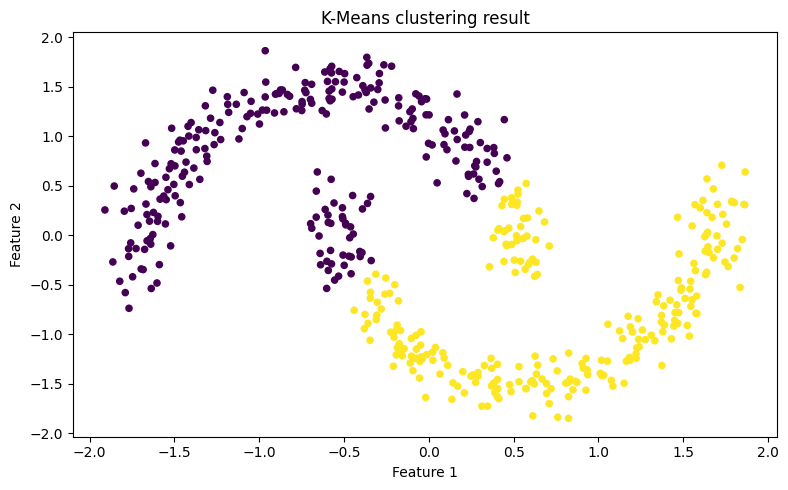

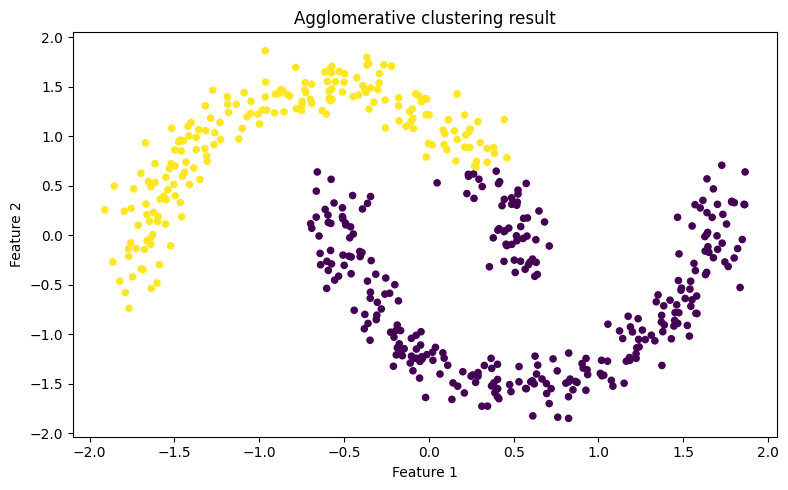

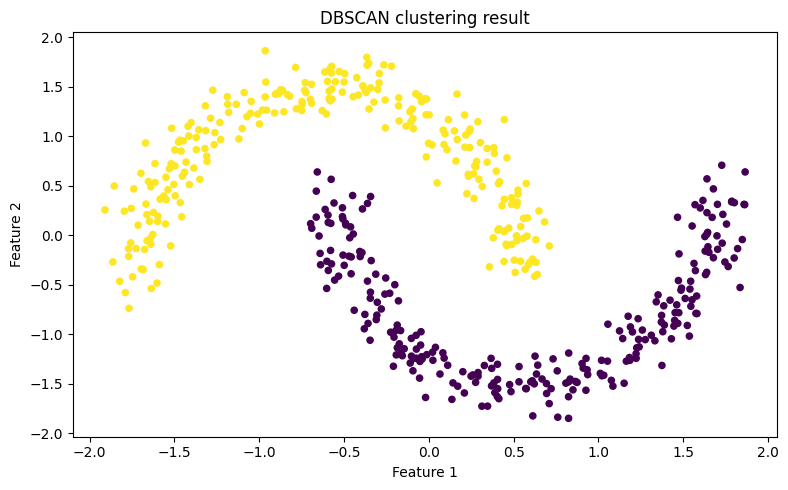

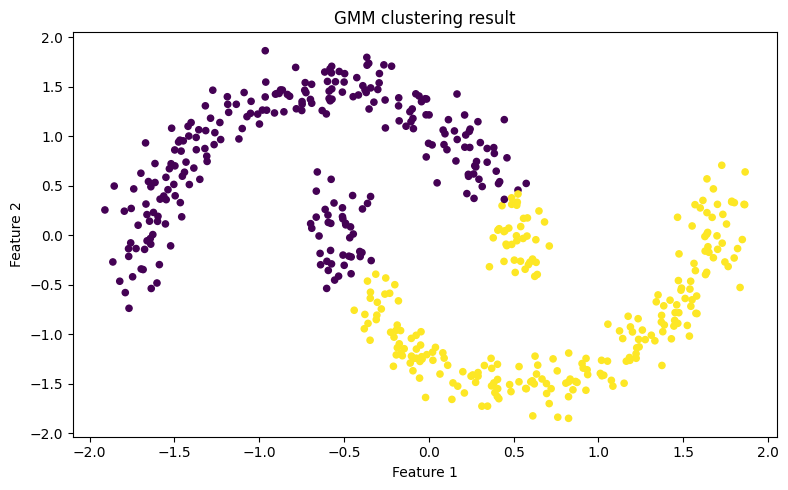

In [18]:
for name, labels in cluster_results.items():
    plt.figure(figsize=(8, 5))
    plt.scatter(
        X_scaled[:, 0],
        X_scaled[:, 1],
        c=labels,
        s=20,
    )
    plt.title(f"{name} clustering result")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.tight_layout()

    filename = name.lower().replace(" ", "_").replace("-", "")
    plt.savefig(IMAGES_DIR / f"{filename}_clusters.png", dpi=200)
    plt.show()

In [19]:
comparison_rows = []

for name, labels in cluster_results.items():
    unique_labels = set(labels)
    cluster_labels = unique_labels - {-1}
    noise_points = int(np.sum(labels == -1))

    if len(cluster_labels) > 1:
        valid_mask = labels != -1
        score = silhouette_score(
            X_scaled[valid_mask],
            labels[valid_mask],
        )
    else:
        score = np.nan

    comparison_rows.append(
        {
            "algorithm": name,
            "clusters_detected": len(cluster_labels),
            "noise_points": noise_points,
            "silhouette_score": score,
        }
    )

comparison = pd.DataFrame(comparison_rows)
comparison

,algorithm,clusters_detected,noise_points,silhouette_score
0,K-Means,2,0,0.493200
1,Agglomerative,2,0,0.452321
2,DBSCAN,2,0,0.383553
3,GMM,2,0,0.493196


## 3. Interpretation

The experiment illustrates that clustering results depend on the assumptions made by each algorithm.

- **K-Means** creates compact regions around centroids and therefore struggles with the curved moon geometry.
- **Agglomerative Clustering** provides a hierarchical construction but its final partition still depends on the selected linkage strategy.
- **DBSCAN** is capable of following the irregular structure of the dataset and can identify isolated observations as noise.
- **GMM** provides probabilistic assignments, but its Gaussian assumption favors elliptical rather than curved clusters.

The silhouette score is useful for comparison, but it should not be treated as the only criterion. Visual inspection, domain knowledge and the objective of the analysis remain essential.

## Conclusion

No clustering algorithm is universally optimal.

This practical comparison confirms that algorithm selection should consider:

- dataset geometry;
- presence of noise;
- expected cluster density;
- interpretability requirements;
- computational cost;
- business or research objectives.

For this moon-shaped dataset, DBSCAN is expected to represent the underlying structure more naturally than centroid-based or Gaussian approaches.

## 4. Bonus: 3D Visualization with the Iris Dataset

The previous experiment used a two-dimensional synthetic dataset to compare clustering behavior.

This additional section uses the Iris dataset, which contains four numerical features, to create a three-dimensional representation of K-Means clusters through Principal Component Analysis (PCA).

PCA is used only for visualization. The clustering model is trained on the standardized original features.

In [20]:
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

iris = load_iris()

X_iris = iris.data

iris_scaler = StandardScaler()
X_iris_scaled = iris_scaler.fit_transform(X_iris)

iris_kmeans = KMeans(
    n_clusters=3,
    random_state=RANDOM_STATE,
    n_init=10,
)

iris_cluster_labels = iris_kmeans.fit_predict(X_iris_scaled)

pca = PCA(n_components=3)
X_iris_pca = pca.fit_transform(X_iris_scaled)

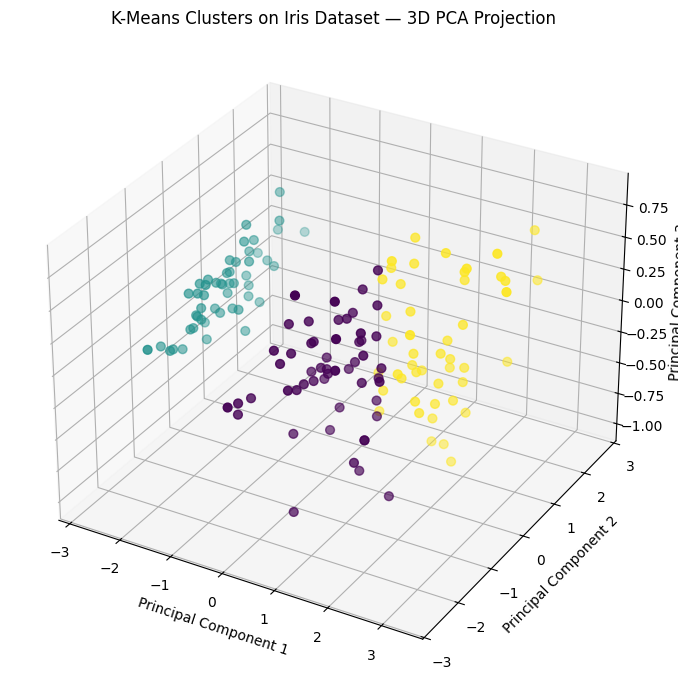

In [21]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    X_iris_pca[:, 0],
    X_iris_pca[:, 1],
    X_iris_pca[:, 2],
    c=iris_cluster_labels,
    s=40,
)

ax.set_title("K-Means Clusters on Iris Dataset — 3D PCA Projection")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")

plt.tight_layout()
plt.savefig(
    IMAGES_DIR / "iris_kmeans_3d.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()


### Interpretation

The three-dimensional PCA projection provides a compact visual representation of the Iris dataset.

K-Means identifies three groups, although some overlap remains because the original classes are not perfectly separable in the reduced space.

This visualization illustrates an important distinction:

- clustering is performed on the standardized original features;
- PCA is used afterwards to represent the result in three dimensions;
- the visual separation should not be interpreted as a perfect measure of clustering quality.